In [2]:
import sys
# sys.path.append('~/where/you/download/the/script/')
import scattering
import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
# import xarray as 
# import cv2
import glob
import torch

use torch backend


In [3]:
# data = np.load(r"C:\Users\oweno\Documents\GitHub\scattering_transform\50_scenes_v1.pkl", allow_pickle=True)
data = np.load('/Users/opodriscoll/Documents/Scripts/sar_cloud/' + '50_scenes_test_v1.pkl', allow_pickle = True)
data.shape

(1951, 128, 128)

In [4]:
M = N = 128; J = 7; L = 4
st_calc = scattering.Scattering2d(M, N, J, L) 

In [105]:
i = 1
s_covs = []
count = 20
while i*count <= data.shape[0]:
    
    s_cov  = st_calc.scattering_cov(data[count*(i-1):count*(i), :,:], if_large_batch = False)
    s_covs.append(s_cov)
    i+=1
    # print(i)

In [39]:
s_covs[0]['S1'].shape, s_covs[0]['C01'].shape

(torch.Size([20, 7, 4]), torch.Size([20, 7, 7, 4, 4]))

In [77]:
J1 = np.arange(J)
J2 = np.arange(J)
S21_scaling = np.float_power(2, np.subtract.outer(J1, J2))
S21_scaling = np.expand_dims(np.expand_dims(np.expand_dims(S21_scaling, 0), -1), -1)

S1 = torch.cat([i['S1'] for i in s_covs])
S1 = np.expand_dims(np.expand_dims(S1, 2), -1)
S2 = torch.cat([i['C01'] for i in s_covs])
S2 = abs(S2)

S21_unscaled = (S2 / S1)

S21 = S21_unscaled / S21_scaling
S21_iso = np.nanmean(S21, axis = (-2,-1))
S21_iso_invar = np.nanmean(S21_iso, axis = (-2,-1))
S21_iso_invar.shape

/var/folders/90/d6h21jb17nz43871lx63sp_141mt08/T/ipykernel_63503/4285680157.py:13: RuntimeWarning: Mean of empty slice
  S21_iso = np.nanmean(S21, axis = (-2,-1))


(1940,)

Text(0.5, 1.0, 'idx: 1935')

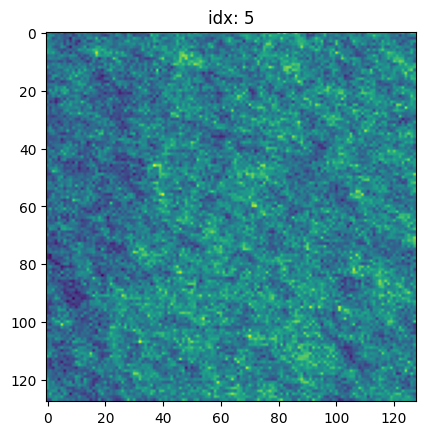

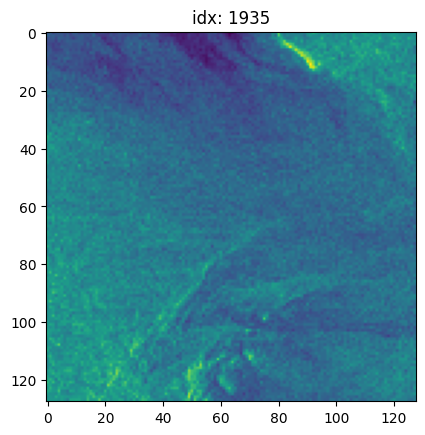

In [152]:
# plt.hist(np.log10(S21_iso_invar))
sparsity_sort = np.argsort(S21_iso_invar)
# np.argmin(S21_iso_invar), np.argmax(S21_iso_invar)
idx = 5
plt.figure()
plt.imshow(data[sparsity_sort[idx], :, :]); plt.title(f"idx: {idx}")
plt.figure()
plt.imshow(data[sparsity_sort[-idx], :, :]); plt.title(f"idx: {len(sparsity_sort) - idx}")

In [161]:
l = np.arange(4)
phis = ((int(L-L/2-1)-l) * np.pi / L) / np.pi
phis

array([ 0.25,  0.  , -0.25, -0.5 ])

In [208]:
idx_perp = np.array([2, 3, 0, 1]) # for these index matches the orientations of l1 w.r.t l2 are perpendicular
S22 = [np.expand_dims(S2[:, :, :, i, i]/ S2[:, :, :, i, idx_perp[i]], 0) for i in range(L)]
S22 = np.concatenate(S21).reshape(np.array(S2.shape[:-1]))
S22_iso = np.nanmean(S22, axis = (-1))
S22_iso_invar = np.nanmean(S22_iso, axis = (-2,-1))
S22_iso_invar.shape

/var/folders/90/d6h21jb17nz43871lx63sp_141mt08/T/ipykernel_63503/217293715.py:4: RuntimeWarning: Mean of empty slice
  S22_iso = np.nanmean(S22, axis = (-1))


(1940,)

Text(0.5, 1.0, 'idx: 1740')

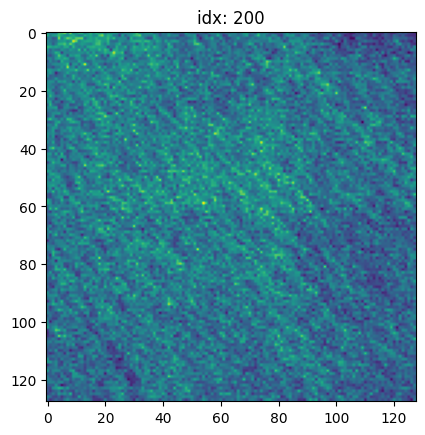

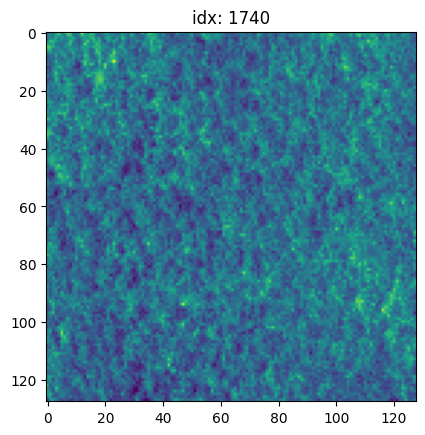

In [212]:
shape_sort = np.argsort(S22_iso_invar)
# np.argmin(S21_iso_invar), np.argmax(S21_iso_invar)
plt.figure()
plt.imshow(data[shape_sort[idx], :, :]); plt.title(f"idx: {idx}")
plt.figure()
plt.imshow(data[shape_sort[-idx], :, :]); plt.title(f"idx: {len(sparsity_sort) - idx}")

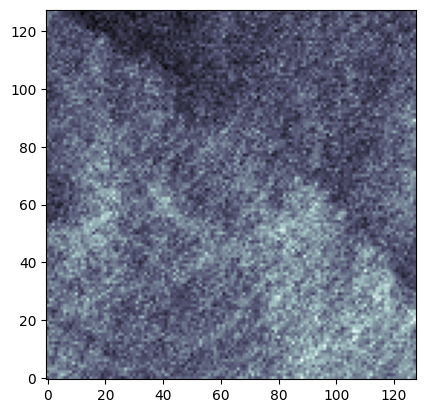

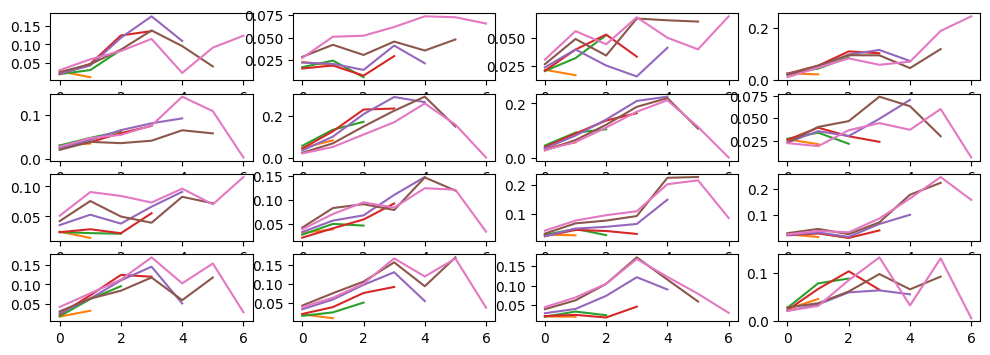

In [132]:
idx = 1231

t = [i['C01'] for i in s_covs]
t = torch.cat(t)

N_fig_y = t[idx].shape[2]
N_fig_x = t[idx].shape[3]

plt.figure()
plt.imshow(data[idx, :, :], cmap = 'bone', origin = 'lower')


fig, (axes) = plt.subplots(N_fig_y, N_fig_x, figsize = (12,4))

for x in range(N_fig_y):
    for y in range(N_fig_x):
        axes[x, y].plot(abs(t[idx][:,:,x,y]))


In [32]:
import torch
torch.cuda.empty_cache()